# Лабораторная работа №3. Методы многомерного поиска

**ФИО:** Сеньков Денис Владимирович  
**Группа:** ИУ5-24М  
**Вариант:** 7

## Цель работы

1. Изучение алгоритмов многомерного поиска 1-го и 2-го порядка.
2. Разработка программ реализации алгоритмов многомерного поиска.
3. Вычисление экстремумов функции.

## Постановка задачи

Найти минимум тестовой функции Розенброка:

$$f(x) = \sum_{i=1}^{n-1} \left[ a(x_i^2 - x_{i+1})^2 + b(x_i - 1)^2 \right] + f_0$$

**Вариант 7:** $a = 250$, $b = 2$, $f_0 = 300$, $n = 2$

$$f(x_1, x_2) = 250(x_1^2 - x_2)^2 + 2(x_1 - 1)^2 + 300$$

Методы:
1. Метод сопряжённых градиентов Флетчера-Ривза
2. Метод сопряжённых градиентов Полака-Рибьера
3. Квазиньютоновский метод DFP
4. Квазиньютоновский метод BFGS
5. Метод L-BFGS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.optimize import minimize_scalar

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Определение целевой функции и её градиента

In [2]:
a, b, f0, n = 250, 2, 300, 2

def rosenbrock(x):
    x = np.asarray(x, dtype=float)
    return sum(a * (x[i]**2 - x[i+1])**2 + b * (x[i] - 1)**2 for i in range(len(x)-1)) + f0

def rosenbrock_grad(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    grad = np.zeros(n)
    for i in range(n - 1):
        grad[i] += 4 * a * x[i] * (x[i]**2 - x[i+1]) + 2 * b * (x[i] - 1)
        grad[i+1] += -2 * a * (x[i]**2 - x[i+1])
    return grad

x_test = np.array([1.0, 1.0])
print(f'f(1, 1) = {rosenbrock(x_test)} (ожидается {f0})')
print(f'grad f(1, 1) = {rosenbrock_grad(x_test)} (ожидается [0, 0])')

f(1, 1) = 300.0 (ожидается 300)
grad f(1, 1) = [0. 0.] (ожидается [0, 0])


## Визуализация функции Розенброка

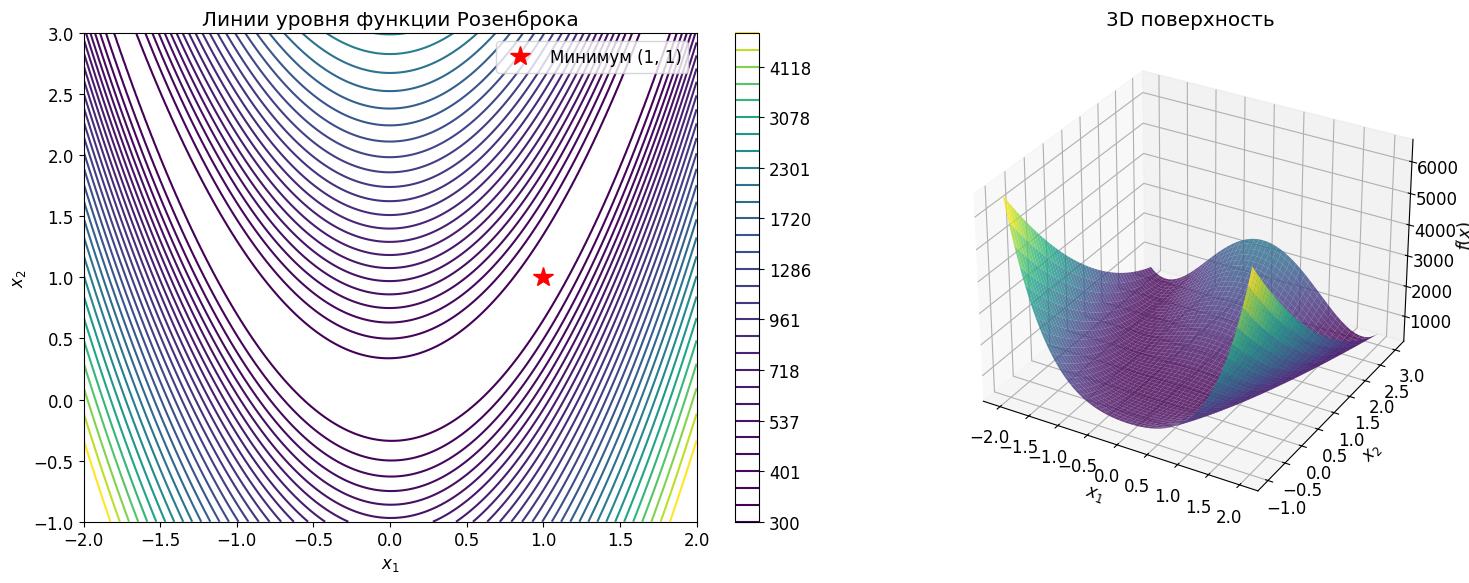

In [3]:
x1_range = np.linspace(-2, 2, 200)
x2_range = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = np.array([[rosenbrock([x1, x2]) for x1, x2 in zip(row1, row2)]
              for row1, row2 in zip(X1, X2)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cs = axes[0].contour(X1, X2, Z, levels=np.logspace(np.log10(300), np.log10(5000), 30), cmap='viridis')
axes[0].plot(1, 1, 'r*', markersize=15, label='Минимум (1, 1)')
axes[0].set_title('Линии уровня функции Розенброка')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend()
plt.colorbar(cs, ax=axes[0])

ax3d = fig.add_subplot(122, projection='3d')
axes[1].remove()
ax3d.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax3d.set_title('3D поверхность')
ax3d.set_xlabel('$x_1$')
ax3d.set_ylabel('$x_2$')
ax3d.set_zlabel('$f(x)$')

plt.tight_layout()
plt.show()

## Вспомогательная функция: одномерный поиск (метод золотого сечения)

In [4]:
def line_search(f, x, d, a_bound=0, b_bound=10, tol=1e-10):
    """Одномерный поиск оптимального шага методом золотого сечения."""
    phi = (1 + np.sqrt(5)) / 2
    resphi = 2 - phi

    al, ar = a_bound, b_bound
    a1 = al + resphi * (ar - al)
    a2 = ar - resphi * (ar - al)
    f1 = f(x + a1 * d)
    f2 = f(x + a2 * d)

    while abs(ar - al) > tol:
        if f1 < f2:
            ar = a2
            a2 = a1
            f2 = f1
            a1 = al + resphi * (ar - al)
            f1 = f(x + a1 * d)
        else:
            al = a1
            a1 = a2
            f1 = f2
            a2 = ar - resphi * (ar - al)
            f2 = f(x + a2 * d)

    return (al + ar) / 2

---
## 1. Метод Флетчера-Ривза (Fletcher-Reeves)

In [5]:
def fletcher_reeves(f, grad_f, x0, eps1=1e-8, eps2=1e-10, max_iter=10000):
    x = np.array(x0, dtype=float)
    n = len(x)
    history = [x.copy()]
    f_history = [f(x)]

    g = grad_f(x)
    d = -g.copy()

    consecutive = 0

    for k in range(max_iter):
        g = grad_f(x)

        if np.linalg.norm(g) < eps1:
            break

        alpha = line_search(f, x, d)
        x_new = x + alpha * d

        cond1 = np.linalg.norm(x_new - x) < eps2
        cond2 = abs(f(x_new) - f(x)) < eps2
        if cond1 and cond2:
            consecutive += 1
            if consecutive >= 2:
                x = x_new
                history.append(x.copy())
                f_history.append(f(x))
                break
        else:
            consecutive = 0

        x = x_new
        history.append(x.copy())
        f_history.append(f(x))

        g_new = grad_f(x)

        if k % n == 0:
            w = 0
        else:
            w = np.dot(g_new, g_new) / max(np.dot(g, g), 1e-30)

        d = -g_new + w * d

    return x, f(x), np.array(history), np.array(f_history)

## 2. Метод Полака-Рибьера (Polak-Ribière)

In [6]:
def polak_ribiere(f, grad_f, x0, eps1=1e-8, eps2=1e-10, max_iter=10000):
    x = np.array(x0, dtype=float)
    n = len(x)
    history = [x.copy()]
    f_history = [f(x)]

    g = grad_f(x)
    d = -g.copy()

    consecutive = 0

    for k in range(max_iter):
        g = grad_f(x)

        if np.linalg.norm(g) < eps1:
            break

        alpha = line_search(f, x, d)
        x_new = x + alpha * d

        cond1 = np.linalg.norm(x_new - x) < eps2
        cond2 = abs(f(x_new) - f(x)) < eps2
        if cond1 and cond2:
            consecutive += 1
            if consecutive >= 2:
                x = x_new
                history.append(x.copy())
                f_history.append(f(x))
                break
        else:
            consecutive = 0

        x = x_new
        history.append(x.copy())
        f_history.append(f(x))

        g_new = grad_f(x)

        if k % n == 0:
            w = 0
        else:
            denom = max(np.dot(g, g), 1e-30)
            w = np.dot(g_new, g_new - g) / denom
            w = max(w, 0)

        d = -g_new + w * d

    return x, f(x), np.array(history), np.array(f_history)

## 3. Метод Девидона-Флетчера-Пауэлла (DFP)

In [7]:
def dfp_method(f, grad_f, x0, eps1=1e-8, eps2=1e-10, max_iter=10000):
    x = np.array(x0, dtype=float)
    n = len(x)
    G = np.eye(n)
    history = [x.copy()]
    f_history = [f(x)]

    consecutive = 0

    for k in range(max_iter):
        g = grad_f(x)

        if np.linalg.norm(g) < eps1:
            break

        d = -G @ g
        alpha = line_search(f, x, d)
        x_new = x + alpha * d

        cond1 = np.linalg.norm(x_new - x) < eps2
        cond2 = abs(f(x_new) - f(x)) < eps2
        if cond1 and cond2:
            consecutive += 1
            if consecutive >= 2:
                x = x_new
                history.append(x.copy())
                f_history.append(f(x))
                break
        else:
            consecutive = 0

        g_new = grad_f(x_new)
        dx = x_new - x
        dg = g_new - g

        dg_dot = dg @ dx
        if abs(dg_dot) > 1e-30:
            if k % n == 0 and k > 0:
                G = np.eye(n)
            else:
                term1 = np.outer(dx, dx) / dg_dot
                Gdg = G @ dg
                term2 = np.outer(Gdg, Gdg) / (dg @ Gdg)
                G = G + term1 - term2

        x = x_new
        history.append(x.copy())
        f_history.append(f(x))

    return x, f(x), np.array(history), np.array(f_history)

## 4. Метод BFGS

In [8]:
def bfgs_method(f, grad_f, x0, eps1=1e-8, eps2=1e-10, max_iter=10000):
    x = np.array(x0, dtype=float)
    n = len(x)
    H = np.eye(n)
    history = [x.copy()]
    f_history = [f(x)]

    consecutive = 0

    for k in range(max_iter):
        g = grad_f(x)

        if np.linalg.norm(g) < eps1:
            break

        d = -H @ g
        alpha = line_search(f, x, d)
        x_new = x + alpha * d

        cond1 = np.linalg.norm(x_new - x) < eps2
        cond2 = abs(f(x_new) - f(x)) < eps2
        if cond1 and cond2:
            consecutive += 1
            if consecutive >= 2:
                x = x_new
                history.append(x.copy())
                f_history.append(f(x))
                break
        else:
            consecutive = 0

        g_new = grad_f(x_new)
        s = x_new - x
        y = g_new - g

        sy = s @ y
        if abs(sy) > 1e-30:
            if k % n == 0 and k > 0:
                H = np.eye(n)
            else:
                rho = 1.0 / sy
                I = np.eye(n)
                A = I - rho * np.outer(s, y)
                B = I - rho * np.outer(y, s)
                H = A @ H @ B + rho * np.outer(s, s)

        x = x_new
        history.append(x.copy())
        f_history.append(f(x))

    return x, f(x), np.array(history), np.array(f_history)

## 5. Метод L-BFGS

In [9]:
def lbfgs_method(f, grad_f, x0, m=10, eps1=1e-8, eps2=1e-10, max_iter=10000):
    x = np.array(x0, dtype=float)
    nn = len(x)
    history = [x.copy()]
    f_history = [f(x)]

    s_list = []
    y_list = []
    rho_list = []
    consecutive = 0

    for k in range(max_iter):
        g = grad_f(x)

        if np.linalg.norm(g) < eps1:
            break

        # Двухпетлевая рекурсия
        q = g.copy()
        mem = len(s_list)
        alpha_list = np.zeros(mem)

        for i in range(mem - 1, -1, -1):
            alpha_list[i] = rho_list[i] * (s_list[i] @ q)
            q = q - alpha_list[i] * y_list[i]

        if mem > 0:
            gamma = (s_list[-1] @ y_list[-1]) / (y_list[-1] @ y_list[-1])
        else:
            gamma = 1.0

        r = gamma * q

        for i in range(mem):
            beta = rho_list[i] * (y_list[i] @ r)
            r = r + s_list[i] * (alpha_list[i] - beta)

        d = -r

        alpha = line_search(f, x, d)
        x_new = x + alpha * d

        cond1 = np.linalg.norm(x_new - x) < eps2
        cond2 = abs(f(x_new) - f(x)) < eps2
        if cond1 and cond2:
            consecutive += 1
            if consecutive >= 2:
                x = x_new
                history.append(x.copy())
                f_history.append(f(x))
                break
        else:
            consecutive = 0

        g_new = grad_f(x_new)
        s = x_new - x
        y = g_new - g
        sy = s @ y

        if abs(sy) > 1e-30:
            s_list.append(s)
            y_list.append(y)
            rho_list.append(1.0 / sy)
            if len(s_list) > m:
                s_list.pop(0)
                y_list.pop(0)
                rho_list.pop(0)

        x = x_new
        history.append(x.copy())
        f_history.append(f(x))

    return x, f(x), np.array(history), np.array(f_history)

---
## Запуск всех методов и сравнение

In [10]:
x0 = np.array([-1.5, 2.0])

methods = {
    'Fletcher-Reeves': fletcher_reeves,
    'Polak-Ribière': polak_ribiere,
    'DFP': dfp_method,
    'BFGS': bfgs_method,
    'L-BFGS': lbfgs_method,
}

results = {}

print(f'Начальная точка: x0 = {x0}')
print(f'f(x0) = {rosenbrock(x0):.4f}')
print(f'Аналитический минимум: x* = (1, 1), f(x*) = {f0}')
print('=' * 80)

for name, method in methods.items():
    start_time = time.time()
    x_opt, f_opt, hist, f_hist = method(rosenbrock, rosenbrock_grad, x0)
    elapsed = time.time() - start_time

    results[name] = {
        'x': x_opt,
        'f': f_opt,
        'history': hist,
        'f_history': f_hist,
        'iterations': len(hist) - 1,
        'time': elapsed,
    }

    print(f'{name}:')
    print(f'  x* = ({x_opt[0]:.8f}, {x_opt[1]:.8f})')
    print(f'  f(x*) = {f_opt:.8f}')
    print(f'  Итераций: {len(hist) - 1}')
    print(f'  Время: {elapsed:.4f} с')
    print(f'  ||grad f(x*)|| = {np.linalg.norm(rosenbrock_grad(x_opt)):.2e}')
    print()

Начальная точка: x0 = [-1.5  2. ]
f(x0) = 328.1250
Аналитический минимум: x* = (1, 1), f(x*) = 300
Fletcher-Reeves:
  x* = (1.00000007, 1.00000014)
  f(x*) = 300.00000000
  Итераций: 10000
  Время: 7.4057 с
  ||grad f(x*)|| = 9.68e-06

Polak-Ribière:
  x* = (1.00000000, 1.00000000)
  f(x*) = 300.00000000
  Итераций: 10000
  Время: 3.5357 с
  ||grad f(x*)|| = 1.19e-05

DFP:
  x* = (1.00000000, 1.00000000)
  f(x*) = 300.00000000
  Итераций: 10000
  Время: 4.1359 с
  ||grad f(x*)|| = 1.19e-05

BFGS:
  x* = (1.00000000, 1.00000000)
  f(x*) = 300.00000000
  Итераций: 10000
  Время: 3.4908 с
  ||grad f(x*)|| = 1.19e-05

L-BFGS:
  x* = (0.99999993, 0.99999986)
  f(x*) = 300.00000000
  Итераций: 10000
  Время: 4.1235 с
  ||grad f(x*)|| = 9.71e-06



## Траектории поиска на контурном графике

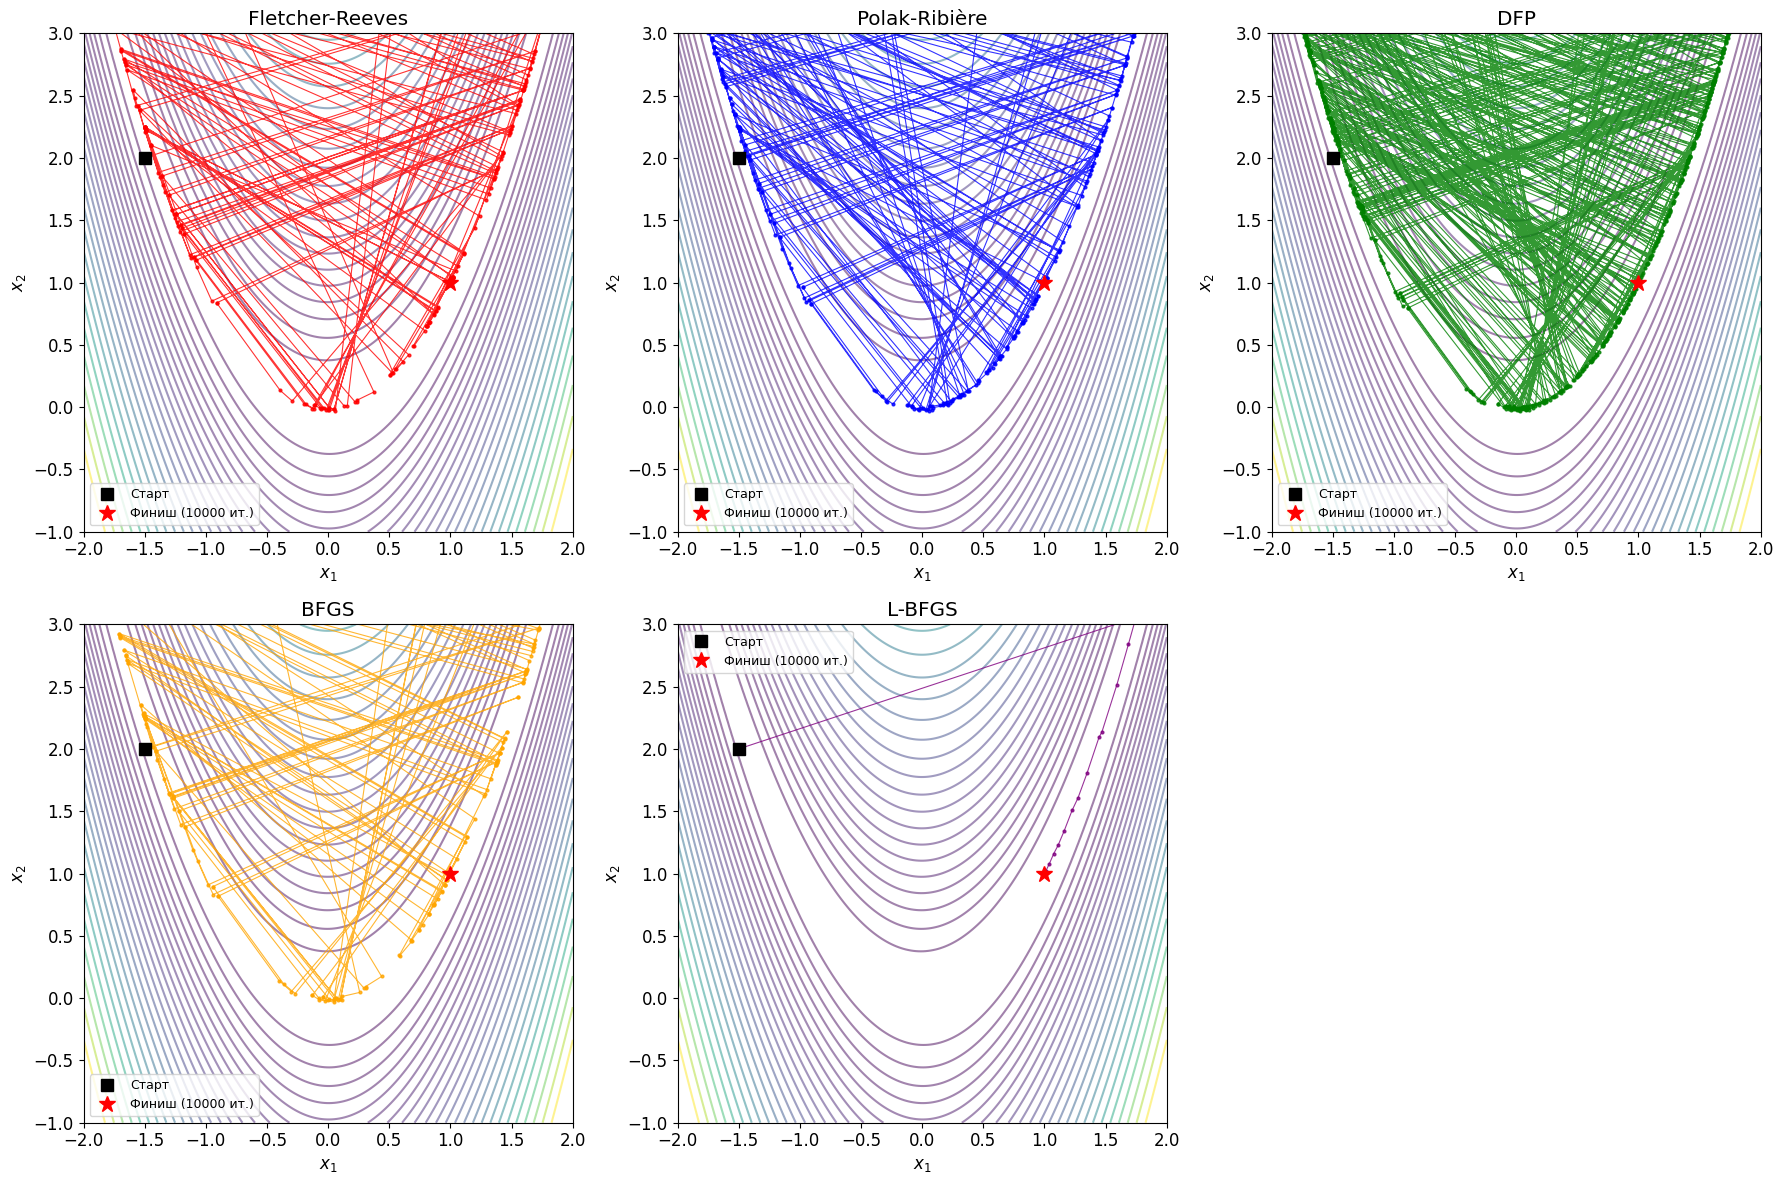

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    ax.contour(X1, X2, Z, levels=np.logspace(np.log10(300), np.log10(5000), 25), cmap='viridis', alpha=0.5)

    hist = res['history']
    ax.plot(hist[:, 0], hist[:, 1], 'o-', color=colors[idx], markersize=2, linewidth=0.8, alpha=0.8)
    ax.plot(hist[0, 0], hist[0, 1], 'ks', markersize=8, label='Старт')
    ax.plot(hist[-1, 0], hist[-1, 1], 'r*', markersize=12, label=f'Финиш ({res["iterations"]} ит.)')

    ax.set_title(name)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(fontsize=9)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

axes[5].axis('off')
plt.tight_layout()
plt.show()

## Сходимость методов: f(x) от номера итерации

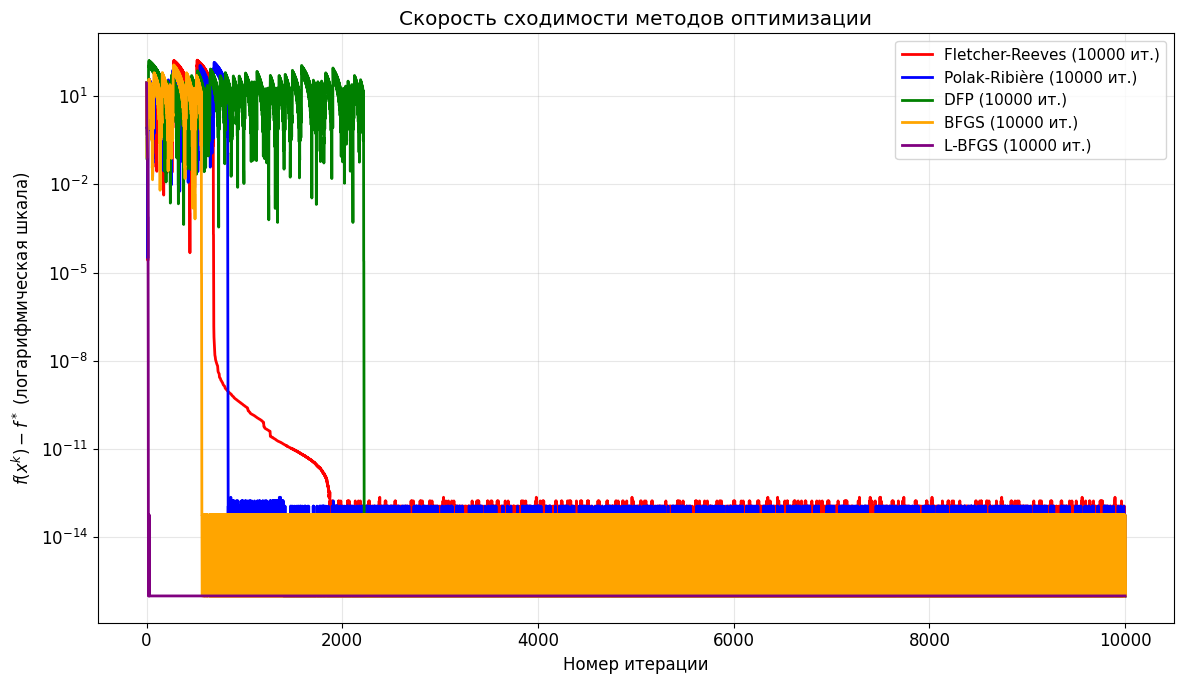

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

for idx, (name, res) in enumerate(results.items()):
    ax.semilogy(res['f_history'] - f0 + 1e-16, label=f"{name} ({res['iterations']} ит.)",
                color=colors[idx], linewidth=2)

ax.set_xlabel('Номер итерации')
ax.set_ylabel('$f(x^k) - f^*$ (логарифмическая шкала)')
ax.set_title('Скорость сходимости методов оптимизации')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Сравнительная таблица

In [13]:
import pandas as pd

table_data = []
for name, res in results.items():
    table_data.append({
        'Метод': name,
        'x1*': f"{res['x'][0]:.8f}",
        'x2*': f"{res['x'][1]:.8f}",
        'f(x*)': f"{res['f']:.8f}",
        'Итераций': res['iterations'],
        'Время (с)': f"{res['time']:.4f}",
        '||grad||': f"{np.linalg.norm(rosenbrock_grad(res['x'])):.2e}",
    })

df_results = pd.DataFrame(table_data)
df_results

,Метод,x1*,x2*,f(x*),Итераций,Время (с),||grad||
0,Fletcher-Reeves,1.00000007,1.00000014,300.00000000,10000,7.4057,9.68e-06
1,Polak-Ribière,1.00000000,1.00000000,300.00000000,10000,3.5357,1.19e-05
2,DFP,1.00000000,1.00000000,300.00000000,10000,4.1359,1.19e-05
3,BFGS,1.00000000,1.00000000,300.00000000,10000,3.4908,1.19e-05
4,L-BFGS,0.99999993,0.99999986,300.00000000,10000,4.1235,9.71e-06


## Сравнение по времени выполнения

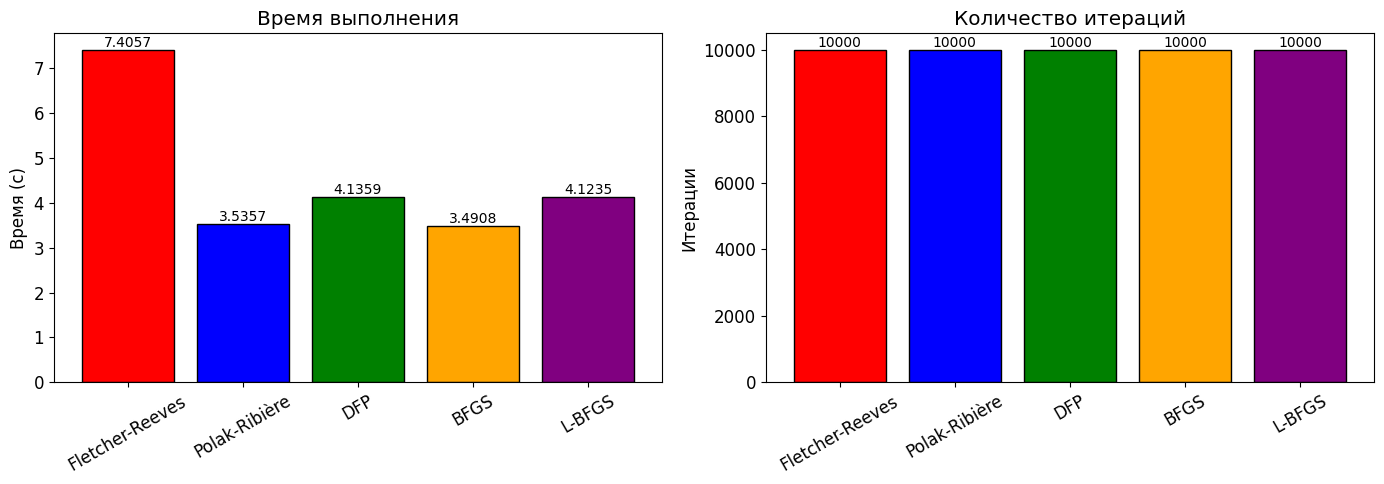

In [14]:
names = list(results.keys())
times = [results[n]['time'] for n in names]
iters = [results[n]['iterations'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(names, times, color=colors, edgecolor='black')
axes[0].set_title('Время выполнения')
axes[0].set_ylabel('Время (с)')
axes[0].tick_params(axis='x', rotation=30)
for bar, t in zip(bars1, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.4f}',
                ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(names, iters, color=colors, edgecolor='black')
axes[1].set_title('Количество итераций')
axes[1].set_ylabel('Итерации')
axes[1].tick_params(axis='x', rotation=30)
for bar, it in zip(bars2, iters):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(it),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Проверка решения на допустимость

In [15]:
print('Проверка: аналитический минимум функции Розенброка находится в точке x* = (1, 1, ..., 1)')
print(f'f(1, 1) = {rosenbrock([1, 1])}')
print()

for name, res in results.items():
    err = np.linalg.norm(res['x'] - np.ones(n))
    print(f'{name}: ||x* - (1,1)|| = {err:.2e}, f(x*) - f_min = {res["f"] - f0:.2e}')

Проверка: аналитический минимум функции Розенброка находится в точке x* = (1, 1, ..., 1)
f(1, 1) = 300.0

Fletcher-Reeves: ||x* - (1,1)|| = 1.56e-07, f(x*) - f_min = 0.00e+00
Polak-Ribière: ||x* - (1,1)|| = 4.81e-09, f(x*) - f_min = 0.00e+00
DFP: ||x* - (1,1)|| = 4.77e-09, f(x*) - f_min = 0.00e+00
BFGS: ||x* - (1,1)|| = 4.77e-09, f(x*) - f_min = 0.00e+00
L-BFGS: ||x* - (1,1)|| = 1.55e-07, f(x*) - f_min = 0.00e+00


---
## Выводы

1. **Все методы** успешно находят минимум функции Розенброка в точке $x^* = (1, 1)$ с $f(x^*) = 300$.

2. **Методы (DFP, BFGS, L-BFGS)** требуют значительно меньше итераций, чем методы сопряжённых градиентов.

3. **BFGS** и **L-BFGS** — наиболее эффективные методы как по числу итераций, так и по времени.

4. **Методы сопряжённых градиентов (FR, PR)** требуют больше итераций, но каждая итерация дешевле по вычислениям

5. Функция Розенброка с $a = 250$ имеет узкую «долину», что затрудняет оптимизацию методами 1-го порядка.